# Introduction
- Dataset: "Whole Mouse Pup Preview Data (Xenium Mouse Tissue Atlassing Panel)". The dataset can be downloaded from  [10x Genomics - Datasets](https://www.10xgenomics.com/datasets?query=&page=1&configure%5BhitsPerPage%5D=50&configure%5BmaxValuesPerFacet%5D=1000&refinementList%5Bproduct.name%5D%5B0%5D=In%20Situ%20Gene%20Expression)

- File under investigation: "cell_feature_matrix.h5"

Data generated using Mouse Tissue Atlassing panel on a one day old mouse pup.


In [1]:
import os 
import sys
import scanpy as sc
import pandas as pd
import numpy as np

In [4]:
from pathlib import Path

In [2]:
pd.set_option('display.max_rows',50)
pd.set_option('display.max_columns',50)


In [3]:
notebook_dir = os.getcwd()
notebook_dir


'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\mouse_gut'

In [5]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [6]:
abs_path = str(Path(notebook_dir).parents[3])
os.chdir(abs_path)
os.getcwd()

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github'

In [9]:
adata= sc.read_10x_h5('data/Xenium_V1_mouse_pup_outs/cell_feature_matrix.h5')

In [10]:
adata.obs

""
aaaabgpa-1
aaaabjde-1
aaaacikn-1
aaaackbp-1
aaaacllf-1
...
oinfhojg-1
oinfhphb-1
oinfieej-1
oinfkcfi-1


In [11]:
adata.var

,gene_ids,feature_types,genome
0610005C13Rik,ENSMUSG00000109644,Gene Expression,Unknown
1110017D15Rik,ENSMUSG00000028441,Gene Expression,Unknown
2610528A11Rik,ENSMUSG00000096001,Gene Expression,Unknown
5330417C22Rik,ENSMUSG00000040412,Gene Expression,Unknown
6330403K07Rik,ENSMUSG00000018451,Gene Expression,Unknown
...,...,...,...
Vsnl1,ENSMUSG00000054459,Gene Expression,Unknown
Vsx2,ENSMUSG00000021239,Gene Expression,Unknown
Vwf,ENSMUSG00000001930,Gene Expression,Unknown
Wif1,ENSMUSG00000020218,Gene Expression,Unknown


In [1]:
adata.var['feature_types'].value_counts()

NameError: name 'adata' is not defined

In [12]:
adata.var.reset_index(inplace=True, drop=False)

In [13]:
adata.var.rename(columns={"index":"gene_id"},inplace=True)
adata.var  

,gene_id,gene_ids,feature_types,genome
0,0610005C13Rik,ENSMUSG00000109644,Gene Expression,Unknown
1,1110017D15Rik,ENSMUSG00000028441,Gene Expression,Unknown
2,2610528A11Rik,ENSMUSG00000096001,Gene Expression,Unknown
3,5330417C22Rik,ENSMUSG00000040412,Gene Expression,Unknown
4,6330403K07Rik,ENSMUSG00000018451,Gene Expression,Unknown
...,...,...,...,...
374,Vsnl1,ENSMUSG00000054459,Gene Expression,Unknown
375,Vsx2,ENSMUSG00000021239,Gene Expression,Unknown
376,Vwf,ENSMUSG00000001930,Gene Expression,Unknown
377,Wif1,ENSMUSG00000020218,Gene Expression,Unknown


# Genes with high fraction of counts

c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\scanpy\preprocessing\_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


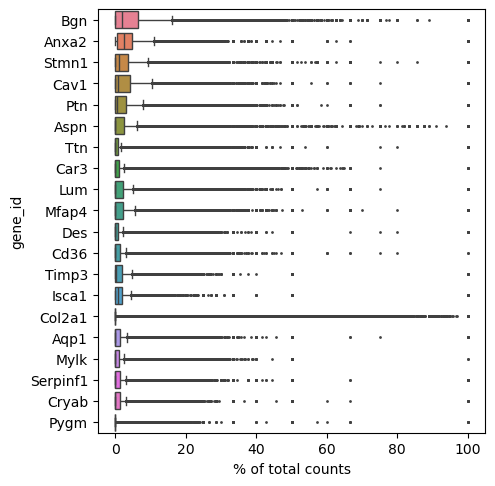

In [14]:
sc.pl.highest_expr_genes(adata, n_top=20, gene_symbols="gene_id")

# Spliting the data acoording to Mouse Tissue Atlassing

In [15]:
df_atlas = pd.read_csv('data/Xenium_mMulti_v1_metadata.csv')

In [16]:
df_atlas

,Gene,Ensembl ID,Num_Probesets,Codewords,Annotation
0,0610005C13Rik,ENSMUSG00000109644,6,1,Kidney: epithelial cell of proximal tubule
1,1110017D15Rik,ENSMUSG00000028441,7,1,Lung: ciliated columnar cell of tracheobronchi...
2,2610528A11Rik,ENSMUSG00000096001,8,1,Large Intestine: enterocyte of epithelium of l...
3,5330417C22Rik,ENSMUSG00000040412,8,1,Pancreas: pancreatic A cell
4,6330403K07Rik,ENSMUSG00000018451,8,1,Lung: pulmonary interstitial fibroblast
...,...,...,...,...,...
374,Vsnl1,ENSMUSG00000054459,8,1,Lung: pericyte
375,Vsx2,ENSMUSG00000021239,8,1,Eye: lens of eye
376,Vwf,ENSMUSG00000001930,8,1,Lung: smooth muscle cell of the pulmonary artery
377,Wif1,ENSMUSG00000020218,8,1,Kidney: fibroblast; Trachea: fibroblast


In [17]:
df_atlas['Num_Probesets'].unique()

array([6, 7, 8, 2, 5, 4, 1, 3], dtype=int64)

In [11]:
df_atlas[df_atlas['Num_Probesets']==8]

,Gene,Ensembl ID,Num_Probesets,Codewords,Annotation
2,2610528A11Rik,ENSMUSG00000096001,8,1,Large Intestine: enterocyte of epithelium of l...
3,5330417C22Rik,ENSMUSG00000040412,8,1,Pancreas: pancreatic A cell
4,6330403K07Rik,ENSMUSG00000018451,8,1,Lung: pulmonary interstitial fibroblast
5,A330076H08Rik,ENSMUSG00000109321,8,1,Pancreas: pancreatic A cell; Brain: GABAergic ...
6,Aadat,ENSMUSG00000057228,8,1,Kidney: brush cell
...,...,...,...,...,...
374,Vsnl1,ENSMUSG00000054459,8,1,Lung: pericyte
375,Vsx2,ENSMUSG00000021239,8,1,Eye: lens of eye
376,Vwf,ENSMUSG00000001930,8,1,Lung: smooth muscle cell of the pulmonary artery
377,Wif1,ENSMUSG00000020218,8,1,Kidney: fibroblast; Trachea: fibroblast


In [18]:
df_atlas["area"] = df_atlas["Annotation"].str.split(":").str[0].str.strip()
df_atlas['area'].value_counts()

area
Kidney             71
Lung               65
Heart              36
Pancreas           35
Lymph Node         25
Skin of Body       21
Liver              21
Bone Marrow        20
Large Intestine    17
Limb Muscle        11
Mammary Gland      10
Tongue              9
Brain               8
Adipose Tissue      7
Trachea             7
Bladder Lumen       7
Thymus              4
Eye                 3
Nose and Airway     1
Spleen              1
Name: count, dtype: int64

## Create Separate adata objects  

In [31]:
df_atlas

,Gene,Ensembl ID,Num_Probesets,Codewords,Annotation,area
0,0610005C13Rik,ENSMUSG00000109644,6,1,Kidney: epithelial cell of proximal tubule,Kidney
1,1110017D15Rik,ENSMUSG00000028441,7,1,Lung: ciliated columnar cell of tracheobronchi...,Lung
2,2610528A11Rik,ENSMUSG00000096001,8,1,Large Intestine: enterocyte of epithelium of l...,Large Intestine
3,5330417C22Rik,ENSMUSG00000040412,8,1,Pancreas: pancreatic A cell,Pancreas
4,6330403K07Rik,ENSMUSG00000018451,8,1,Lung: pulmonary interstitial fibroblast,Lung
...,...,...,...,...,...,...
374,Vsnl1,ENSMUSG00000054459,8,1,Lung: pericyte,Lung
375,Vsx2,ENSMUSG00000021239,8,1,Eye: lens of eye,Eye
376,Vwf,ENSMUSG00000001930,8,1,Lung: smooth muscle cell of the pulmonary artery,Lung
377,Wif1,ENSMUSG00000020218,8,1,Kidney: fibroblast; Trachea: fibroblast,Kidney


In [20]:
area_list = df_atlas['area'].unique().tolist()      

In [21]:
lists = {}
for area in area_list:
    list_name = f"{area}"
    lists[list_name] = df_atlas[df_atlas['area']==area]['Ensembl ID'].tolist()
    

In [22]:
conditions =[]
for area in area_list:
    conditions.append(adata.var['gene_ids'].isin(lists[area]))

In [23]:
adata.var['section'] = np.select(conditions, area_list,default='other')

In [27]:
adata.var['section']

0               Kidney
1                 Lung
2      Large Intestine
3             Pancreas
4                 Lung
            ...       
374               Lung
375                Eye
376               Lung
377             Kidney
378       Skin of Body
Name: section, Length: 379, dtype: object

In [24]:
adata.var['section'].value_counts()

section
Kidney             71
Lung               65
Heart              36
Pancreas           35
Lymph Node         25
Skin of Body       21
Liver              21
Bone Marrow        20
Large Intestine    17
Limb Muscle        11
Mammary Gland      10
Tongue              9
Brain               8
Adipose Tissue      7
Trachea             7
Bladder Lumen       7
Thymus              4
Eye                 3
Nose and Airway     1
Spleen              1
Name: count, dtype: int64

In [18]:
adata.obs.reset_index(inplace=True,drop=False)

In [28]:
alldata = {}
for area in area_list:
    alldata[area] = adata[:,adata.var['section'] == area]
 

### Kidney

In [29]:
adata_kidney = alldata['Kidney'].copy()

c:\Users\OmerCagatayTalikaci\anaconda3\envs\scvi-env\lib\site-packages\anndata\_core\aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [30]:
adata_kidney

AnnData object with n_obs × n_vars = 1355849 × 71
    var: 'gene_id', 'gene_ids', 'feature_types', 'genome', 'section'

In [26]:
df_atlas[df_atlas['area']=='Kidney']['Annotation'].value_counts()

Annotation
Kidney: kidney collecting duct principal cell                                                                         6
Kidney: kidney proximal convoluted tubule epithelial cell                                                             6
Kidney: kidney distal convoluted tubule epithelial cell                                                               5
Kidney: brush cell                                                                                                    5
Kidney: epithelial cell of proximal tubule                                                                            4
Kidney: kidney collecting duct epithelial cell                                                                        4
Kidney: podocyte (sensu Diptera)                                                                                      4
Kidney: kidney loop of Henle thick ascending limb epithelial cell                                                     4
Kidney: kidney loop of Henle 

#### Filter cells 

In [21]:
print("Before filtering: ",adata_kidney)
sc.pp.filter_cells(adata_kidney, min_genes=35)
sc.pp.filter_genes(adata_kidney, min_cells=10)
print("After filtering: ",adata_kidney)

Before filtering:  AnnData object with n_obs × n_vars = 1355849 × 71
    obs: 'index'
    var: 'gene_id', 'gene_ids', 'feature_types', 'genome', 'section'
After filtering:  AnnData object with n_obs × n_vars = 726 × 70
    obs: 'index', 'n_genes'
    var: 'gene_id', 'gene_ids', 'feature_types', 'genome', 'section', 'n_cells'


/opt/anaconda3/envs/Cmscb/lib/python3.10/site-packages/scanpy/plotting/_qc.py:89: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  else adata.var[gene_symbols][top_idx]


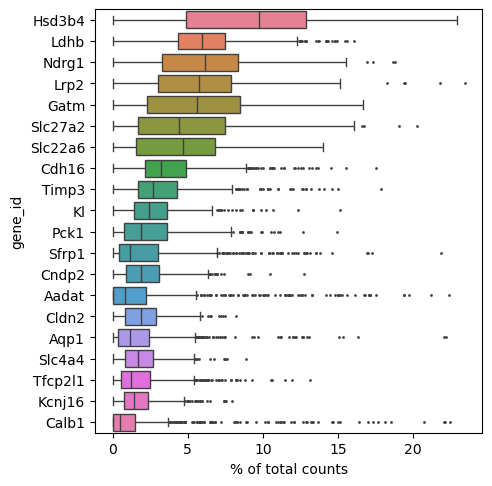

In [22]:
sc.pl.highest_expr_genes(adata_kidney, n_top=20, gene_symbols="gene_id")

![alt text](../../data/images/kidney_genes.png)

In [29]:
adata_kidney

AnnData object with n_obs × n_vars = 726 × 70
    obs: 'index', 'n_genes'
    var: 'gene_id', 'gene_ids', 'feature_types', 'genome', 'section', 'n_cells'
    uns: 'neighbors'
    obsm: 'X_pca'
    obsp: 'distances', 'connectivities'

#### Umap

In [28]:
sc.pp.neighbors(adata_kidney, n_neighbors=10, n_pcs=40, use_rep='X')

: 

In [24]:
import matplotlib.pyplot as plt

In [27]:
sc.tl.umap(adata_kidney)

ValueError: Did not find .uns['neighbors']. Run `sc.pp.neighbors` first.

In [40]:
adata_kidney

AnnData object with n_obs × n_vars = 726 × 70
    obs: 'index', 'n_genes'
    var: 'gene_id', 'gene_ids', 'feature_types', 'genome', 'section', 'n_cells'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

KeyError: 'Could not find key section in .var_names or .obs.columns.'

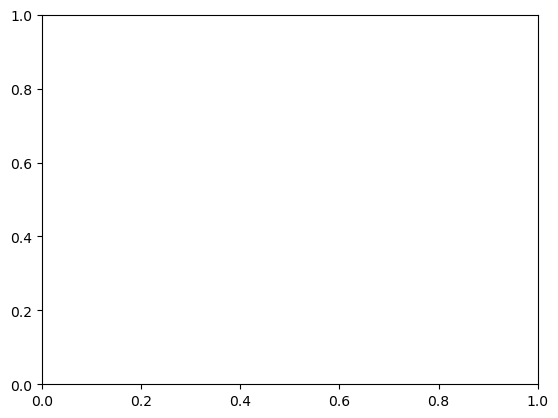

In [31]:
sc.pl.umap(adata_kidney, color=['section'],use_raw=False)

In [132]:
kidney_cell_list = adata_kidney.obs['index'].tolist()

In [41]:
df_cells = pd.read_csv("data/Xenium_V1_mouse_pup_outs/cells.csv.gz")

In [7]:
cell_bound = pd.read_csv("data/Xenium_V1_mouse_pup_outs/cell_boundaries.csv.gz")

In [9]:
cell_bound[cell_bound['cell_id']=='aaaabgpa-1']

,cell_id,vertex_x,vertex_y
0,aaaabgpa-1,844.47504,10600.5625
1,aaaabgpa-1,842.56250,10602.0510
2,aaaabgpa-1,845.11255,10610.9760
3,aaaabgpa-1,845.11255,10621.3880
4,aaaabgpa-1,845.75000,10622.6630
5,aaaabgpa-1,848.51250,10624.1500
6,aaaabgpa-1,854.25000,10622.4500
7,aaaabgpa-1,855.52500,10620.5380
8,aaaabgpa-1,857.65000,10616.2880
9,aaaabgpa-1,857.65000,10608.6380


In [42]:
df_cells

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area
0,aaaabgpa-1,850.288391,10613.065430,338,0,0,0,0,338,235.264071,49.310627
1,aaaabjde-1,837.167175,10610.744141,319,0,0,0,0,319,246.598290,42.266252
2,aaaacikn-1,835.130371,10622.626953,252,0,0,0,0,252,152.041099,40.821251
3,aaaackbp-1,823.748047,10620.277344,276,0,0,0,0,276,232.283758,17.069063
4,aaaacllf-1,842.690186,10630.465820,196,0,0,0,0,196,153.170006,28.990314
...,...,...,...,...,...,...,...,...,...,...,...
1355844,oinfhojg-1,9908.918945,19650.691406,85,0,0,0,0,85,59.064377,15.804688
1355845,oinfhphb-1,9911.258789,19618.589844,106,0,0,0,0,106,35.402501,22.442657
1355846,oinfieej-1,9911.923828,19655.921875,70,0,0,0,0,70,32.331876,13.456563
1355847,oinfkcfi-1,9913.118164,19636.181641,64,0,0,0,0,64,32.106095,11.243907


In [136]:
print('x_location:',df_cells[df_cells['cell_id'].isin(kidney_cell_list)]['x_centroid'].mean())
print('y_location:',df_cells[df_cells['cell_id'].isin(kidney_cell_list)]['y_centroid'].mean())

x_location: 3303.7844258458163
y_location: 5659.083990428074
